In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import pandas as pd
import os
plt.rcParams.update({'font.size': 18})

In [2]:
all_methods =['Nexullance_OPT',
            'Nexullance_MP_APST_4',
            'Nexullance_IT']

In [3]:
raw_data = {}
for method in all_methods:
    raw_data[method] = pd.read_csv(method+".csv")


In [4]:
raw_data["Nexullance_IT"].head()

,topo,V,D,EPR,traffic,ave_phi,std_phi,ave_time[s],std_time[s],ave_PeakRAM[B],std_PeakRAM[B]
0,DDF,36,5,3,uniform,5.896843,0.0,0.112901,0.000138,193,0.0
1,DDF,36,5,3,shift-half,3.350783,0.0,0.019691,0.000131,193,0.0
2,DDF,36,5,3,nearst-neighbour,9.907408,0.0,0.003699,0.000020,193,0.0
3,DDF,36,5,3,shift-1,10.000000,0.0,0.003810,0.000045,193,0.0
4,DDF,36,5,3,router-cluster,5.683056,0.0,0.064095,0.002018,193,0.0


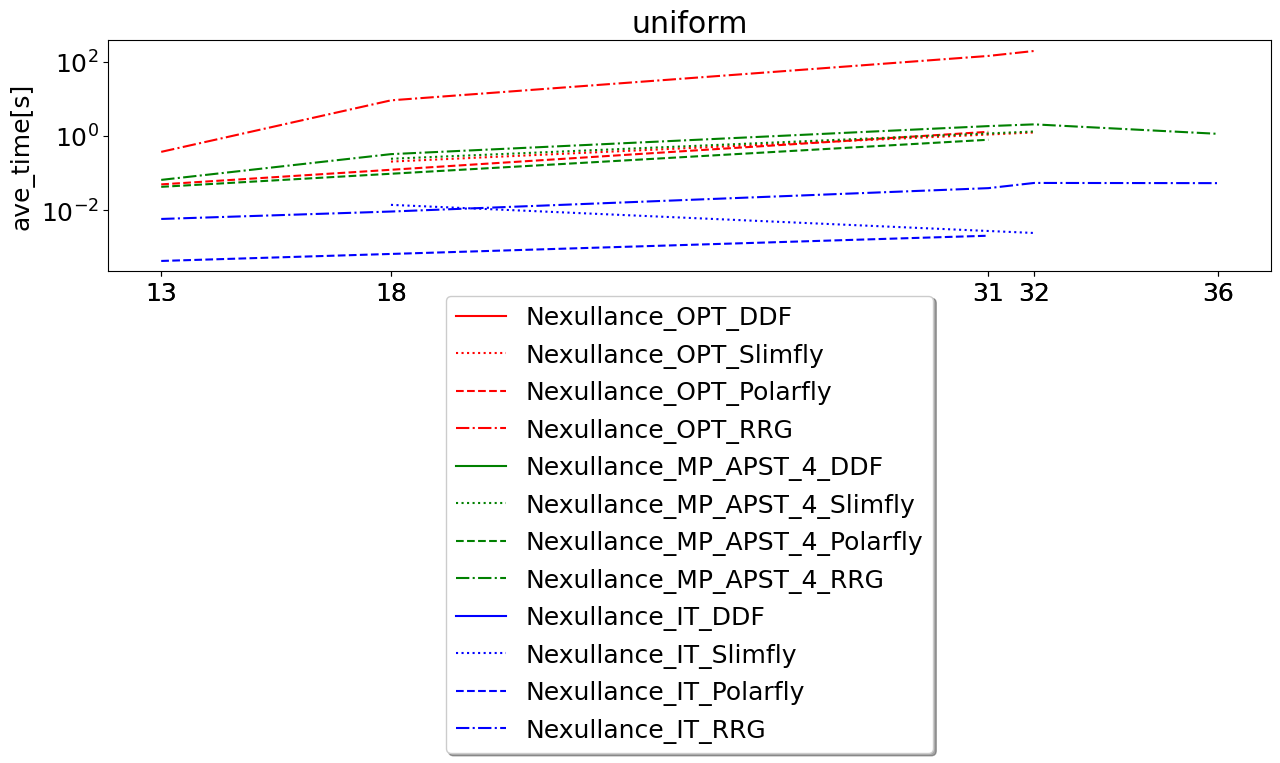

In [8]:
traffic_pattern = "uniform"

color_for_method={'Nexullance_OPT': 'r',
                'Nexullance_MP_APST_4': 'g',
                'Nexullance_IT': 'b'}

linestyle_for_topo={'DDF': 'solid',
                'Slimfly': 'dotted',
                'Polarfly': 'dashed',
                'RRG': 'dashdot'}

plt.figure(figsize=(15, 3))  # Adjust size if necessary
for method in all_methods:
    data_of_method = raw_data[method]
    data_of_method = data_of_method[data_of_method["traffic"] == traffic_pattern]
    for topo in data_of_method["topo"].unique():
        data_of_topo = data_of_method[data_of_method["topo"] == topo]
        plt.plot(data_of_topo["V"], data_of_topo["ave_time[s]"], label=method + "_" + topo, 
                 color=color_for_method[method], linestyle=linestyle_for_topo[topo])


plt.xlabel("V")
plt.xticks(data_of_method["V"].values)
plt.ylabel("ave_time[s]")
plt.yscale('log')
plt.title(traffic_pattern)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05),
          fancybox=True, shadow=True)
plt.show()

